# Simple pendulum

[Moreno Marzolla](https://www.moreno.marzolla.name)

---

<img src="pendulum.svg" width="30%"/>

A simple pendulum swinging under Earth's gravity can be described as a second-order differential equation:

$$
\theta''(t) + \frac{g}{l} \sin( \theta(t) ) = 0
$$

where $\theta(t)$ is the angle of the pendulum, $\omega(t)$ the angular velocity, $l$ is the length of the pendulum and $g$ the gravitational acceleration on the surfate of Earth ($g \approx 9.8067 \mathrm{m}\mathrm{s}^{-2}$).

To solve the equation, it is necessary to transform it to a set of first-order differential equations as follows:

$$
\left\{\begin{align}
\theta'(t) &= \omega(t)\\
\omega'(t) &=  - \displaystyle\frac{g}{l} \sin \theta(t)
\end{align}\right.
$$

We can solve the equation numerically using Python. First of all, let us import a few libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
%matplotlib inline

The, we define a function `pendulum(x0, t, l)` that describes the differential equation to be solved. 
`x0` is the system state $(\theta(t), \omega(t))$, $t$ is the time, and $l$ is the length of the pendulum. The function returns a pair $\left( \omega(t), -g/l \sin \omega(t) \right)$ representing the right-hand side of the differential equations above.

In [2]:
# See https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.odeint.html
def pend(x0, t, l):
    theta, omega = x0
    g = 9.8067
    dxdt = [omega, - g/l*np.sin(theta)]
    return dxdt

Then, function `odependulum(initial_state)` will compute the evolution of the pendulum starting from a given initial conrfiguration $( \theta(0), \omega(0) )$ (initial angle, intial radial velocity). The function returns a pair of arrays, that are the values of $\theta(t)$ and $\omega(t)$ for $t=0, \ldots T$.

In [3]:
def odependulum(x0, t):
    l = 1; # m
    sol = odeint(pend, x0, t, args=(l,));
    theta = sol[:,0]
    omega = sol[:,1]
    return theta,omega;

Let us plot the system state as a function fo the time $t$ starting with initial conditions $\theta(0) = \pi - 0.1, \omega(0) = 0$.

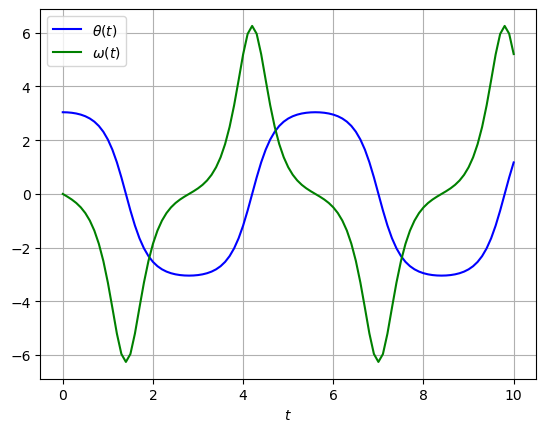

In [4]:
t = np.linspace(0, 10, 101);
theta,omega = odependulum([np.pi - 0.1, 0.0], t)
plt.plot(t, theta, 'b', label='$\\theta(t)$')
plt.plot(t, omega, 'g', label='$\\omega(t)$')
plt.legend(loc='best')
plt.xlabel('$t$')
plt.grid()
plt.show()

Let us plot the _phase portrait_ for several initial angles; in all cases, the initial velocity is zero.

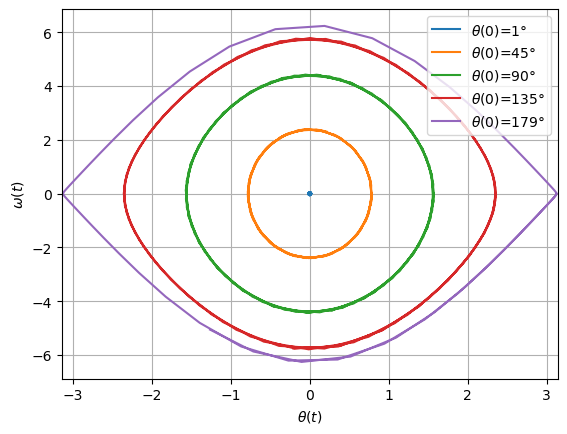

In [5]:
for ang0 in [1, 45, 90, 135, 179]: 
    theta,omega = odependulum([np.deg2rad(ang0), 0.0], t)
    plt.plot(theta, omega, label=f"$\\theta(0)$={ang0:d}°")
plt.legend(loc='best')
plt.xlim(-np.pi, np.pi)
plt.xlabel("$\\theta(t)$")
plt.ylabel("$\\omega(t)$")
plt.grid()
plt.savefig("pendulum-phase-portrait.png")
plt.show()

See [examples](https://en.wikipedia.org/wiki/Pendulum_(mechanics)#Examples)